In [2]:
# ============================================
# WEEK 10: CUSTOMER CHURN PREDICTION
# DATA PREPROCESSING & FEATURE ENGINEERING
# ============================================

# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

from sklearn.model_selection import train_test_split

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load dataset

df = pd.read_csv("churn_data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# Check number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 500
Number of columns: 9


In [5]:
# Display first five rows

df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [6]:
# Display last five rows

df.tail()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
495,C00496,50,128,6970,Month-to-month,Credit Card,Yes,1,0
496,C00497,2,49,5917,Two year,Bank Transfer,No,1,0
497,C00498,46,198,2158,Month-to-month,Bank Transfer,No,0,0
498,C00499,1,185,5755,Two year,Credit Card,Yes,1,1
499,C00500,27,181,4292,Month-to-month,Bank Transfer,No,1,0


In [7]:
# Display random sample

df.sample(5, random_state=42)

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
361,C00362,5,134,3651,One year,Credit Card,Yes,1,1
73,C00074,2,152,2038,Month-to-month,Bank Transfer,No,0,1
374,C00375,29,20,4628,One year,Bank Transfer,Yes,1,0
155,C00156,26,148,4601,One year,Bank Transfer,Yes,0,0
104,C00105,3,115,5547,Two year,Bank Transfer,No,0,1


In [8]:
# Check data types

df.dtypes

CustomerID            str
Tenure              int64
MonthlyCharges      int64
TotalCharges        int64
Contract              str
PaymentMethod         str
PaperlessBilling      str
SeniorCitizen       int64
Churn               int64
dtype: object

In [9]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   CustomerID        500 non-null    str  
 1   Tenure            500 non-null    int64
 2   MonthlyCharges    500 non-null    int64
 3   TotalCharges      500 non-null    int64
 4   Contract          500 non-null    str  
 5   PaymentMethod     500 non-null    str  
 6   PaperlessBilling  500 non-null    str  
 7   SeniorCitizen     500 non-null    int64
 8   Churn             500 non-null    int64
dtypes: int64(5), str(4)
memory usage: 35.3 KB


In [10]:
# Statistical summary of numerical columns

df.describe()

,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000
std,20.667057,51.799903,2260.619837,0.500497,0.308146
min,1.000000,20.000000,159.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000


In [11]:
# Statistical summary of categorical columns

df.describe(include="object")

C:\Users\hp\AppData\Local\Temp\ipykernel_3824\479739612.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,CustomerID,Contract,PaymentMethod,PaperlessBilling
count,500,500,500,500
unique,500,3,3,2
top,C00001,One year,Credit Card,No
freq,1,186,178,257


In [12]:
# Check missing values

missing_values = df.isnull().sum()

print(missing_values)

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64


In [13]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [14]:
# Display unique values for each column

for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique())


CustomerID:
<StringArray>
['C00001', 'C00002', 'C00003', 'C00004', 'C00005', 'C00006', 'C00007',
 'C00008', 'C00009', 'C00010',
 ...
 'C00491', 'C00492', 'C00493', 'C00494', 'C00495', 'C00496', 'C00497',
 'C00498', 'C00499', 'C00500']
Length: 500, dtype: str

Tenure:
[ 6 21 27 53 16 55 66 61 64 14 59  7  8 65 19 42 26 38 25 60 30 47 20 36
 34 28 10 43 32 50 37 62 63 22 56 49 71 31  9 58 23  3  2 69 68 13 70 35
  4 41 51 40 18 15 39 44 48 33 52 46 11 29  5 45  1 24 57 67 12 54 17]

MonthlyCharges:
[ 64 113  31  29 185  44  99 128 124 120  57 110  86 158  58  77 187 101
 156 105 137  40 100 193 181  56 175 190 196 182 195 116  42 166  84 151
  20 148  89 123  93 170  46 162  49 121 172 154  48  68 157  54  72  38
 176 180 140  61  62 102  21 153 125 152  43 109  95 138 139 142 141 136
 103 108 177 126 188 122 150 143 130  78  39 115  75  59  24  88  87 111
 160 164  98  83 107 147 114  50 183 179 174  79  92  28 134  67 184 112
 167  47 173 133 132  90 171  80 145  76 135 199 163  51  3

## Analyze the churn distribution


In [15]:
# Count churn values

churn_counts = df["Churn"].value_counts()

print(churn_counts)

Churn
0    447
1     53
Name: count, dtype: int64


In [16]:
# Calculate churn percentages

churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
0    89.4
1    10.6
Name: proportion, dtype: float64


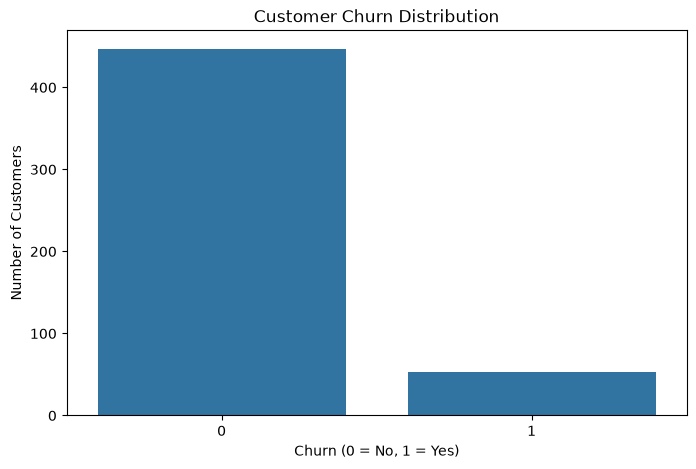

In [17]:
# Plot churn distribution

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

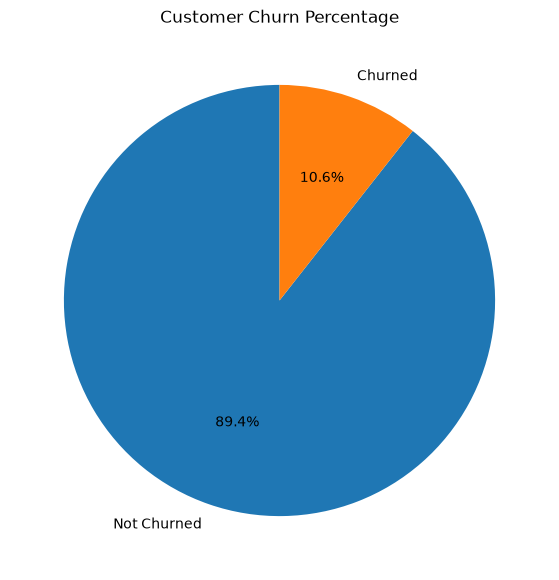

In [18]:
# Pie chart for churn distribution

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    churn_counts,
    labels=["Not Churned", "Churned"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")

plt.show()

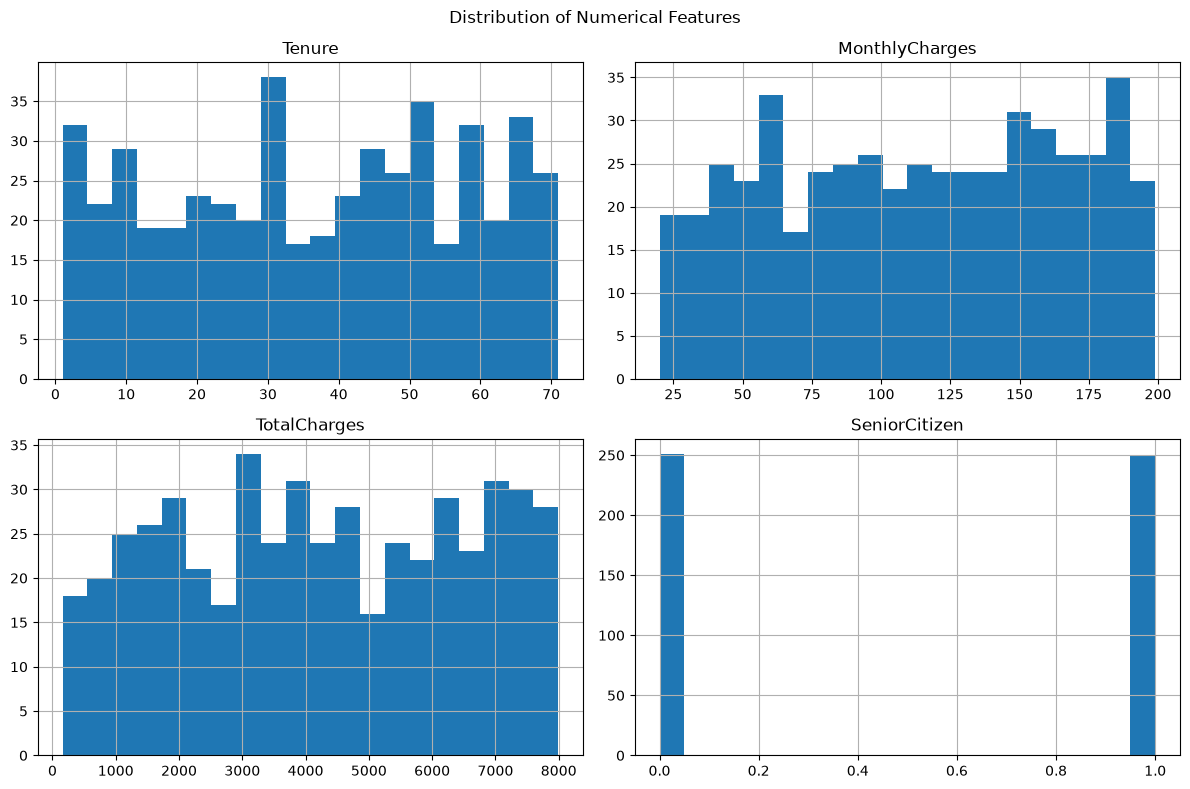

In [19]:
# Numerical columns

numerical_columns = [
    "Tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen"
]

# Plot numerical distributions

df[numerical_columns].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")

plt.tight_layout()

plt.show()

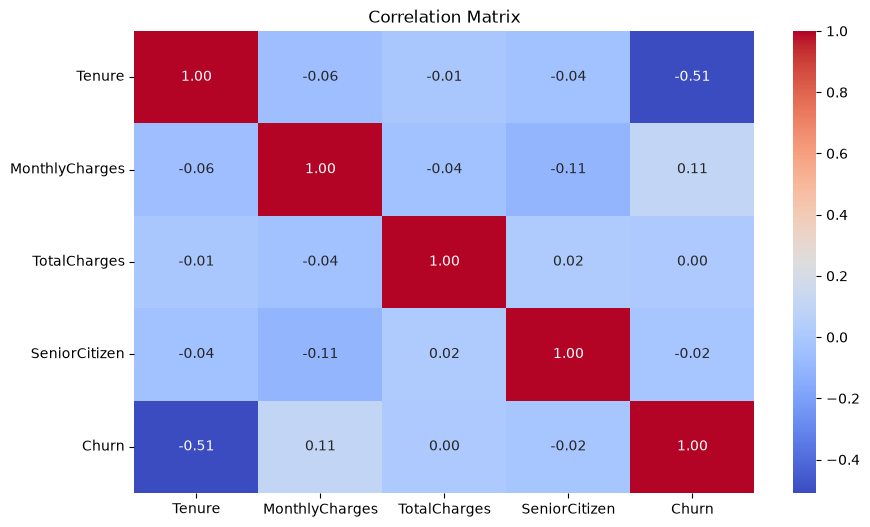

In [20]:
# Correlation matrix

correlation_matrix = df[numerical_columns + ["Churn"]].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [21]:
categorical_columns = [
    "Contract",
    "PaymentMethod",
    "PaperlessBilling"
]

In [22]:
# Analyze categorical columns

for column in categorical_columns:
    print(f"\nValue counts for {column}:")
    print(df[column].value_counts())


Value counts for Contract:
Contract
One year          186
Month-to-month    170
Two year          144
Name: count, dtype: int64

Value counts for PaymentMethod:
PaymentMethod
Credit Card         178
Electronic Check    163
Bank Transfer       159
Name: count, dtype: int64

Value counts for PaperlessBilling:
PaperlessBilling
No     257
Yes    243
Name: count, dtype: int64


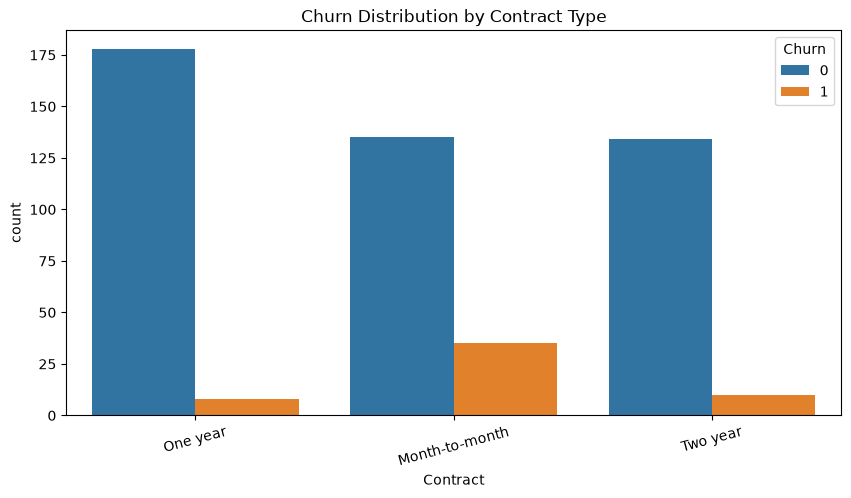

In [23]:
# Churn by contract type

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn Distribution by Contract Type")

plt.xticks(rotation=15)

plt.show()

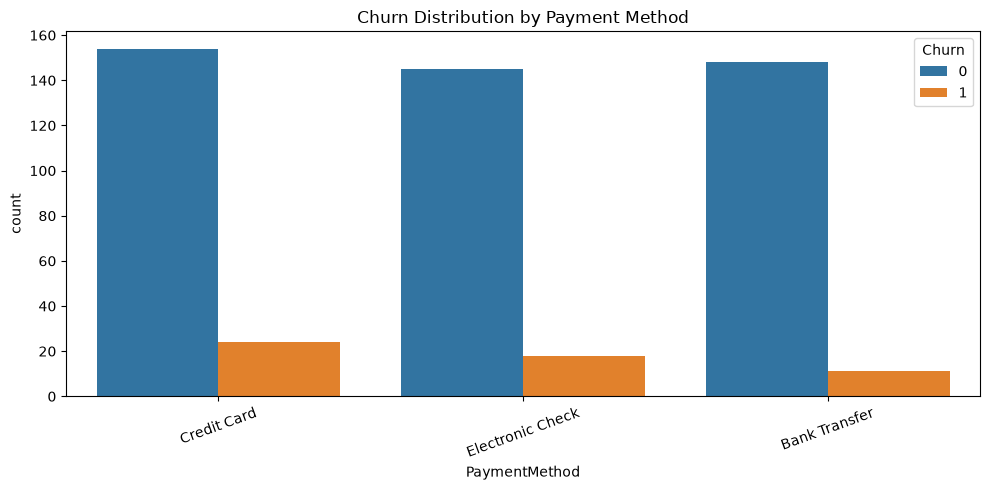

In [24]:
# Churn by payment method

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Churn Distribution by Payment Method")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

# Categorical Data Encoding

## Objectives

1. Apply Label Encoding
2. Apply One-Hot Encoding
3. Apply Ordinal Encoding
4. Compare encoding techniques
5. Understand the importance of encoding in machine learning

In [25]:
# ============================================
# CATEGORICAL DATA ENCODING
# ============================================

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder
)

print("Encoding libraries imported successfully!")

Encoding libraries imported successfully!


In [26]:
# Define categorical columns

categorical_columns = [
    "Contract",
    "PaymentMethod",
    "PaperlessBilling"
]

# Display categorical data

df[categorical_columns].head()

,Contract,PaymentMethod,PaperlessBilling
0,One year,Credit Card,No
1,Month-to-month,Electronic Check,Yes
2,Two year,Credit Card,No
3,Month-to-month,Electronic Check,No
4,One year,Electronic Check,No


## 1. Label Encoding

Label Encoding converts categorical values into numerical labels.
It is useful for target variables and certain categorical features.

For nominal input features, arbitrary numerical labels can imply
a false ordering, so the encoding choice should be justified.

In [27]:
# ============================================
# LABEL ENCODING
# ============================================

# Create a copy of the dataset

df_label = df.copy()

# Initialize encoder

label_encoder = LabelEncoder()

# Encode PaperlessBilling

df_label["PaperlessBilling_Encoded"] = label_encoder.fit_transform(
    df_label["PaperlessBilling"]
)

# Display results

df_label[
    ["PaperlessBilling", "PaperlessBilling_Encoded"]
].head(10)

,PaperlessBilling,PaperlessBilling_Encoded
0,No,0
1,Yes,1
2,No,0
3,No,0
4,No,0
5,No,0
6,No,0
7,No,0
8,No,0
9,Yes,1


In [28]:
# Display mapping

mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

print("Label Encoding Mapping:")
print(mapping)

Label Encoding Mapping:
{'No': np.int64(0), 'Yes': np.int64(1)}


## 2. One-Hot Encoding

One-Hot Encoding converts categorical values into separate
binary columns. It is suitable for nominal categorical features.

In [29]:
# ============================================
# ONE-HOT ENCODING
# ============================================

# Initialize encoder

one_hot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Fit and transform categorical columns

encoded_array = one_hot_encoder.fit_transform(
    df[categorical_columns]
)

# Convert to DataFrame

encoded_df = pd.DataFrame(
    encoded_array,
    columns=one_hot_encoder.get_feature_names_out(
        categorical_columns
    ),
    index=df.index
)

# Display results

encoded_df.head()

,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank Transfer,PaymentMethod_Credit Card,PaymentMethod_Electronic Check,PaperlessBilling_No,PaperlessBilling_Yes
0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


In [30]:
# Numerical columns

numerical_columns = [
    "Tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen"
]

# Combine numerical and encoded categorical features

df_onehot = pd.concat(
    [
        df[numerical_columns],
        encoded_df,
        df[["Churn"]]
    ],
    axis=1
)

# Display result

df_onehot.head()

,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank Transfer,PaymentMethod_Credit Card,PaymentMethod_Electronic Check,PaperlessBilling_No,PaperlessBilling_Yes,Churn
0,6,64,1540,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0
1,21,113,1753,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0
2,27,31,1455,1,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0
3,53,29,7150,1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0
4,16,185,1023,1,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0


In [31]:
# ============================================
# ORDINAL ENCODING
# ============================================

contract_order = [
    "Month-to-month",
    "One year",
    "Two year"
]

ordinal_encoder = OrdinalEncoder(
    categories=[contract_order],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

contract_encoded = ordinal_encoder.fit_transform(
    df[["Contract"]]
)

contract_ordinal_df = pd.DataFrame(
    contract_encoded,
    columns=["Contract_Ordinal"],
    index=df.index
)

pd.concat(
    [
        df[["Contract"]],
        contract_ordinal_df
    ],
    axis=1
).head(10)

,Contract,Contract_Ordinal
0,One year,1.0
1,Month-to-month,0.0
2,Two year,2.0
3,Month-to-month,0.0
4,One year,1.0
5,Two year,2.0
6,Two year,2.0
7,Month-to-month,0.0
8,Month-to-month,0.0
9,One year,1.0


In [32]:
print(df["Contract"].unique())

<StringArray>
['One year', 'Month-to-month', 'Two year']
Length: 3, dtype: str


In [33]:
print("Original dataset shape:", df.shape)
print("One-hot encoded shape:", df_onehot.shape)
print("Encoding completed successfully!")

Original dataset shape: (500, 9)
One-hot encoded shape: (500, 13)
Encoding completed successfully!


In [34]:
# ============================================
# VALIDATE ENCODED DATA
# ============================================

# Check data types

print(df_onehot.dtypes)

Tenure                              int64
MonthlyCharges                      int64
TotalCharges                        int64
SeniorCitizen                       int64
Contract_Month-to-month           float64
Contract_One year                 float64
Contract_Two year                 float64
PaymentMethod_Bank Transfer       float64
PaymentMethod_Credit Card         float64
PaymentMethod_Electronic Check    float64
PaperlessBilling_No               float64
PaperlessBilling_Yes              float64
Churn                               int64
dtype: object


In [35]:
# Check missing values in encoded dataset

print("Missing values:")
print(df_onehot.isnull().sum().sum())

Missing values:
0


In [36]:
# Display unique values of encoded columns

encoded_columns = encoded_df.columns.tolist()

for column in encoded_columns:
    print(f"{column}: {df_onehot[column].unique()}")

Contract_Month-to-month: [0. 1.]
Contract_One year: [1. 0.]
Contract_Two year: [0. 1.]
PaymentMethod_Bank Transfer: [0. 1.]
PaymentMethod_Credit Card: [1. 0.]
PaymentMethod_Electronic Check: [0. 1.]
PaperlessBilling_No: [1. 0.]
PaperlessBilling_Yes: [0. 1.]


In [37]:
# Final shape validation

assert df_onehot.shape[0] == df.shape[0]

print("Shape validation passed!")

Shape validation passed!


In [38]:
# ============================================
# FINAL ENCODING VALIDATION
# ============================================

# Check missing values

print("Total missing values:", df_onehot.isnull().sum().sum())

# Check duplicate rows

print("Duplicate rows:", df_onehot.duplicated().sum())

# Validate row count

assert df_onehot.shape[0] == df.shape[0]

print("Row count validation passed!")

# Display final shape

print("Final encoded dataset shape:", df_onehot.shape)

Total missing values: 0
Duplicate rows: 0
Row count validation passed!
Final encoded dataset shape: (500, 13)


#  Feature Scaling

Feature scaling transforms numerical features into comparable
ranges. In this section, Min-Max Scaling and Standardization
will be applied and compared.

In [39]:
# ============================================
# DAY 3: FEATURE SCALING
# ============================================

from sklearn.preprocessing import MinMaxScaler, StandardScaler

print("Scaling libraries imported successfully!")

Scaling libraries imported successfully!


In [40]:
# Select numerical columns

numerical_columns = [
    "Tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen"
]

# Display numerical features

df[numerical_columns].head()

,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen
0,6,64,1540,1
1,21,113,1753,1
2,27,31,1455,1
3,53,29,7150,1
4,16,185,1023,1


In [41]:
# ============================================
# MIN-MAX SCALING
# ============================================

# Initialize scaler

minmax_scaler = MinMaxScaler()

# Fit and transform numerical columns

minmax_scaled = minmax_scaler.fit_transform(
    df[numerical_columns]
)

# Convert to DataFrame

df_minmax = pd.DataFrame(
    minmax_scaled,
    columns=numerical_columns,
    index=df.index
)

# Display scaled data

df_minmax.head()

,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen
0,0.071429,0.245810,0.176305,1.0
1,0.285714,0.519553,0.203498,1.0
2,0.371429,0.061453,0.165454,1.0
3,0.742857,0.050279,0.892506,1.0
4,0.214286,0.921788,0.110303,1.0


In [42]:
# ============================================
# STANDARD SCALING
# ============================================

# Initialize scaler

standard_scaler = StandardScaler()

# Fit and transform numerical columns

standard_scaled = standard_scaler.fit_transform(
    df[numerical_columns]
)

# Convert to DataFrame

df_standard = pd.DataFrame(
    standard_scaled,
    columns=numerical_columns,
    index=df.index
)

# Display scaled data

df_standard.head()

,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen
0,-1.478807,-0.959185,-1.194621,1.004008
1,-0.752287,-0.012290,-1.100305,1.004008
2,-0.461679,-1.596890,-1.232259,1.004008
3,0.797622,-1.635539,1.289485,1.004008
4,-0.994460,1.379066,-1.423548,1.004008


In [43]:
# ============================================
# COMPARE SCALING TECHNIQUES
# ============================================

print("Original Data:")
display(df[numerical_columns].head())

print("\nMin-Max Scaled Data:")
display(df_minmax.head())

print("\nStandard Scaled Data:")
display(df_standard.head())

Original Data:


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen
0,6,64,1540,1
1,21,113,1753,1
2,27,31,1455,1
3,53,29,7150,1
4,16,185,1023,1



Min-Max Scaled Data:


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen
0,0.071429,0.245810,0.176305,1.0
1,0.285714,0.519553,0.203498,1.0
2,0.371429,0.061453,0.165454,1.0
3,0.742857,0.050279,0.892506,1.0
4,0.214286,0.921788,0.110303,1.0



Standard Scaled Data:


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen
0,-1.478807,-0.959185,-1.194621,1.004008
1,-0.752287,-0.012290,-1.100305,1.004008
2,-0.461679,-1.596890,-1.232259,1.004008
3,0.797622,-1.635539,1.289485,1.004008
4,-0.994460,1.379066,-1.423548,1.004008


In [44]:
# Check Min-Max range

print("Min-Max Scaling Range:")
print(df_minmax.agg(["min", "max"]))

# Check Standard Scaling statistics

print("\nStandard Scaling Statistics:")
print(df_standard.agg(["mean", "std"]))

Min-Max Scaling Range:
     Tenure  MonthlyCharges  TotalCharges  SeniorCitizen
min     0.0             0.0           0.0            0.0
max     1.0             1.0           1.0            1.0

Standard Scaling Statistics:
            Tenure  MonthlyCharges  TotalCharges  SeniorCitizen
mean  1.731948e-16    8.881784e-17  1.767475e-16  -6.750156e-17
std   1.001002e+00    1.001002e+00  1.001002e+00   1.001002e+00


In [45]:
# ============================================
# STANDARD SCALING
# ============================================

from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler

standard_scaler = StandardScaler()

# Fit and transform numerical columns

standard_scaled = standard_scaler.fit_transform(
    df[numerical_columns]
)

# Convert to DataFrame

df_standard = pd.DataFrame(
    standard_scaled,
    columns=numerical_columns,
    index=df.index
)

# Display scaled data

df_standard.head()

,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen
0,-1.478807,-0.959185,-1.194621,1.004008
1,-0.752287,-0.012290,-1.100305,1.004008
2,-0.461679,-1.596890,-1.232259,1.004008
3,0.797622,-1.635539,1.289485,1.004008
4,-0.994460,1.379066,-1.423548,1.004008


In [46]:
# ============================================
# COMPARE SCALING TECHNIQUES
# ============================================

print("Original Data:")
display(df[numerical_columns].head())

print("\nMin-Max Scaled Data:")
display(df_minmax.head())

print("\nStandard Scaled Data:")
display(df_standard.head())

Original Data:


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen
0,6,64,1540,1
1,21,113,1753,1
2,27,31,1455,1
3,53,29,7150,1
4,16,185,1023,1



Min-Max Scaled Data:


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen
0,0.071429,0.245810,0.176305,1.0
1,0.285714,0.519553,0.203498,1.0
2,0.371429,0.061453,0.165454,1.0
3,0.742857,0.050279,0.892506,1.0
4,0.214286,0.921788,0.110303,1.0



Standard Scaled Data:


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen
0,-1.478807,-0.959185,-1.194621,1.004008
1,-0.752287,-0.012290,-1.100305,1.004008
2,-0.461679,-1.596890,-1.232259,1.004008
3,0.797622,-1.635539,1.289485,1.004008
4,-0.994460,1.379066,-1.423548,1.004008


In [47]:
# Check scaling statistics

print("Min-Max Scaling:")
print(df_minmax.agg(["min", "max"]))

print("\nStandard Scaling:")
print(df_standard.agg(["mean", "std"]))

Min-Max Scaling:
     Tenure  MonthlyCharges  TotalCharges  SeniorCitizen
min     0.0             0.0           0.0            0.0
max     1.0             1.0           1.0            1.0

Standard Scaling:
            Tenure  MonthlyCharges  TotalCharges  SeniorCitizen
mean  1.731948e-16    8.881784e-17  1.767475e-16  -6.750156e-17
std   1.001002e+00    1.001002e+00  1.001002e+00   1.001002e+00


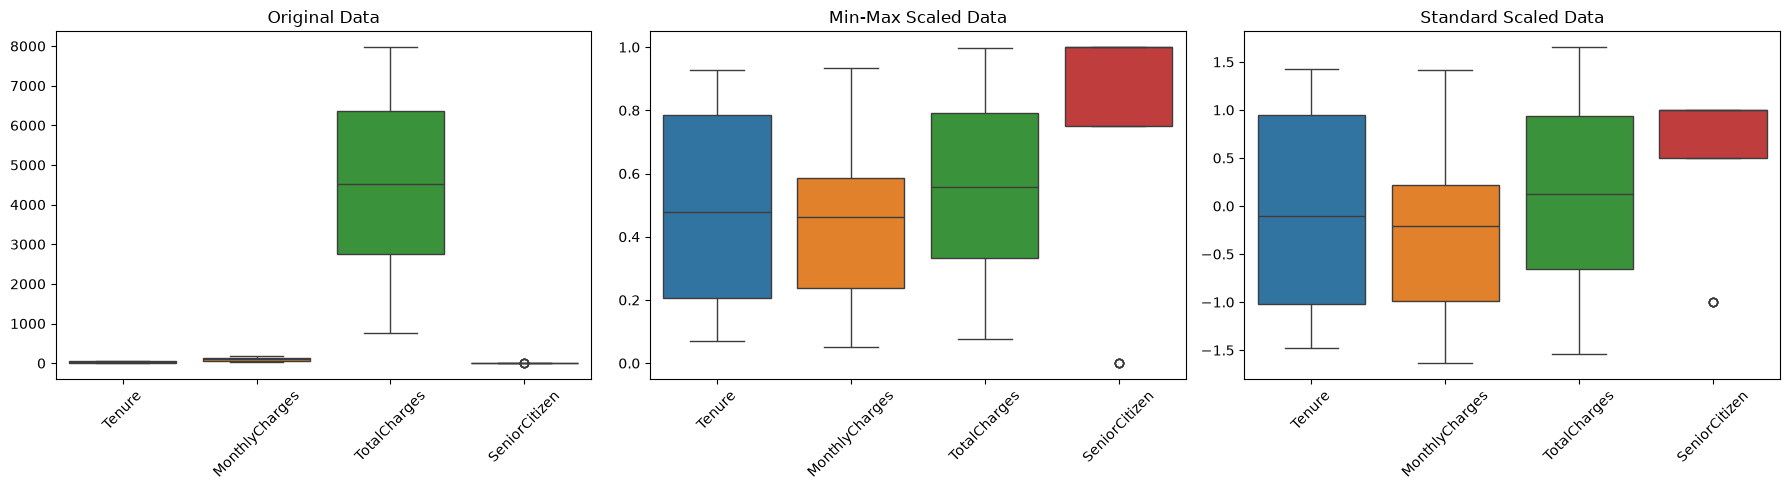

In [48]:
# ============================================
# SCALING COMPARISON VISUALIZATION
# ============================================

# Select first 20 rows for visualization

sample_size = 20

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

# Original data

sns.boxplot(
    data=df[numerical_columns].iloc[:sample_size],
    ax=axes[0]
)

axes[0].set_title("Original Data")
axes[0].tick_params(axis="x", rotation=45)

# Min-Max scaled data

sns.boxplot(
    data=df_minmax.iloc[:sample_size],
    ax=axes[1]
)

axes[1].set_title("Min-Max Scaled Data")
axes[1].tick_params(axis="x", rotation=45)

# Standard scaled data

sns.boxplot(
    data=df_standard.iloc[:sample_size],
    ax=axes[2]
)

axes[2].set_title("Standard Scaled Data")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.show()

In [49]:
# Compare original and scaled ranges

comparison = pd.DataFrame({
    "Original_Min": df[numerical_columns].min(),
    "Original_Max": df[numerical_columns].max(),
    "MinMax_Min": df_minmax.min(),
    "MinMax_Max": df_minmax.max(),
    "Standard_Mean": df_standard.mean(),
    "Standard_Std": df_standard.std(ddof=0)
})

comparison

,Original_Min,Original_Max,MinMax_Min,MinMax_Max,Standard_Mean,Standard_Std
Tenure,1,71,0.0,1.0,1.731948e-16,1.0
MonthlyCharges,20,199,0.0,1.0,8.881784e-17,1.0
TotalCharges,159,7992,0.0,1.0,1.767475e-16,1.0
SeniorCitizen,0,1,0.0,1.0,-6.750156e-17,1.0


## Outlier Detection and Handling

In [50]:
# Continuous numerical features
continuous_columns = [
    "Tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[continuous_columns].describe()

,Tenure,MonthlyCharges,TotalCharges
count,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000
std,20.667057,51.799903,2260.619837
min,1.000000,20.000000,159.000000
25%,19.000000,67.000000,2237.250000
50%,37.000000,115.000000,4182.500000
75%,54.000000,158.000000,6266.750000
max,71.000000,199.000000,7992.000000


In [51]:
# IQR Outlier Detection

outlier_summary = []

for column in continuous_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Tenure,19.00,54.00,35.0,-33.5,106.5,0
1,MonthlyCharges,67.00,158.00,91.0,-69.5,294.5,0
2,TotalCharges,2237.25,6266.75,4029.5,-3807.0,12311.0,0


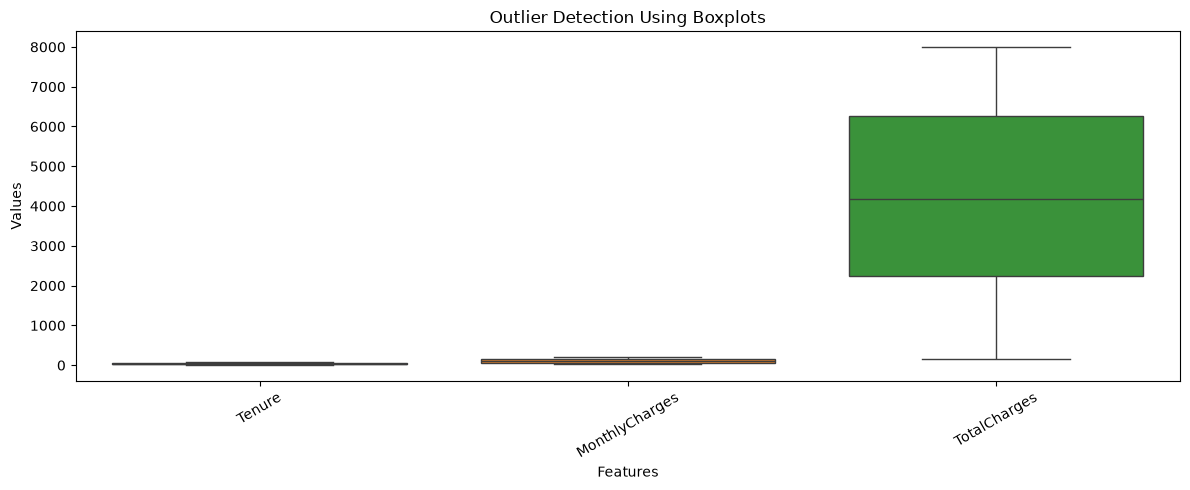

In [52]:
# Visualize outliers using boxplots

plt.figure(figsize=(12, 5))

sns.boxplot(data=df[continuous_columns])

plt.title("Outlier Detection Using Boxplots")
plt.xlabel("Features")
plt.ylabel("Values")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [53]:
from scipy.stats import zscore

# Calculate absolute Z-scores
z_scores = np.abs(zscore(df[continuous_columns]))

# Count values with Z-score greater than 3
zscore_outlier_counts = (z_scores > 3).sum(axis=0)

zscore_summary_df = pd.DataFrame({
    "Feature": continuous_columns,
    "ZScore_Outlier_Count": zscore_outlier_counts
})

zscore_summary_df

,Feature,ZScore_Outlier_Count
0,Tenure,0
1,MonthlyCharges,0
2,TotalCharges,0


## Feature Engineering

In [54]:
# Create a copy for feature engineering
df_engineered = df.copy()

# Display original columns
print("Original columns:")
print(df_engineered.columns.tolist())

Original columns:
['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn']


In [55]:
# Average monthly spending
df_engineered["AverageMonthlySpend"] = (
    df_engineered["TotalCharges"] /
    df_engineered["Tenure"]
)

# Estimated annual charges
df_engineered["EstimatedAnnualCharges"] = (
    df_engineered["MonthlyCharges"] * 12
)

df_engineered[
    [
        "Tenure",
        "MonthlyCharges",
        "TotalCharges",
        "AverageMonthlySpend",
        "EstimatedAnnualCharges"
    ]
].head()

,Tenure,MonthlyCharges,TotalCharges,AverageMonthlySpend,EstimatedAnnualCharges
0,6,64,1540,256.666667,768
1,21,113,1753,83.476190,1356
2,27,31,1455,53.888889,372
3,53,29,7150,134.905660,348
4,16,185,1023,63.937500,2220


In [56]:
# Create tenure groups

df_engineered["TenureGroup"] = pd.cut(
    df_engineered["Tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "New Customer",
        "Short Term",
        "Medium Term",
        "Long Term"
    ]
)

df_engineered[
    ["Tenure", "TenureGroup"]
].head(10)

,Tenure,TenureGroup
0,6,New Customer
1,21,Short Term
2,27,Medium Term
3,53,Long Term
4,16,Short Term
5,55,Long Term
6,66,Long Term
7,61,Long Term
8,64,Long Term
9,14,Short Term


In [57]:
# Identify long-term contracts

df_engineered["IsLongTermContract"] = np.where(
    df_engineered["Contract"].isin(["One year", "Two year"]),
    1,
    0
)

df_engineered[
    ["Contract", "IsLongTermContract"]
].head(10)

,Contract,IsLongTermContract
0,One year,1
1,Month-to-month,0
2,Two year,1
3,Month-to-month,0
4,One year,1
5,Two year,1
6,Two year,1
7,Month-to-month,0
8,Month-to-month,0
9,One year,1


In [58]:
# Identify electronic check users

df_engineered["IsElectronicCheck"] = np.where(
    df_engineered["PaymentMethod"] == "Electronic check",
    1,
    0
)

df_engineered[
    ["PaymentMethod", "IsElectronicCheck"]
].head(10)

,PaymentMethod,IsElectronicCheck
0,Credit Card,0
1,Electronic Check,0
2,Credit Card,0
3,Electronic Check,0
4,Electronic Check,0
5,Electronic Check,0
6,Bank Transfer,0
7,Bank Transfer,0
8,Credit Card,0
9,Bank Transfer,0


In [59]:
# Convert paperless billing into a numerical feature

df_engineered["HasPaperlessBilling"] = np.where(
    df_engineered["PaperlessBilling"] == "Yes",
    1,
    0
)

df_engineered[
    ["PaperlessBilling", "HasPaperlessBilling"]
].head(10)

,PaperlessBilling,HasPaperlessBilling
0,No,0
1,Yes,1
2,No,0
3,No,0
4,No,0
5,No,0
6,No,0
7,No,0
8,No,0
9,Yes,1


In [60]:
# Display the new feature columns

new_features = [
    "AverageMonthlySpend",
    "EstimatedAnnualCharges",
    "TenureGroup",
    "IsLongTermContract",
    "IsElectronicCheck",
    "HasPaperlessBilling"
]

df_engineered[new_features].head(10)

,AverageMonthlySpend,EstimatedAnnualCharges,TenureGroup,IsLongTermContract,IsElectronicCheck,HasPaperlessBilling
0,256.666667,768,New Customer,1,0,0
1,83.476190,1356,Short Term,0,0,1
2,53.888889,372,Medium Term,1,0,0
3,134.905660,348,Long Term,0,0,0
4,63.937500,2220,Short Term,1,0,0
5,137.054545,528,Long Term,1,0,0
6,63.303030,1188,Long Term,1,0,0
7,50.622951,1536,Long Term,0,0,0
8,124.578125,1488,Long Term,0,0,0
9,417.428571,1440,Short Term,1,0,1


In [61]:
# Validate the engineered dataset

print("Original dataset shape:", df.shape)
print("Engineered dataset shape:", df_engineered.shape)

print("\nNew features:")
for feature in new_features:
    print("-", feature)

print("\nMissing values in new features:")
print(df_engineered[new_features].isnull().sum())

print("\nEngineered dataset preview:")
display(df_engineered.head())

Original dataset shape: (500, 9)
Engineered dataset shape: (500, 15)

New features:
- AverageMonthlySpend
- EstimatedAnnualCharges
- TenureGroup
- IsLongTermContract
- IsElectronicCheck
- HasPaperlessBilling

Missing values in new features:
AverageMonthlySpend       0
EstimatedAnnualCharges    0
TenureGroup               0
IsLongTermContract        0
IsElectronicCheck         0
HasPaperlessBilling       0
dtype: int64

Engineered dataset preview:


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,AverageMonthlySpend,EstimatedAnnualCharges,TenureGroup,IsLongTermContract,IsElectronicCheck,HasPaperlessBilling
0,C00001,6,64,1540,One year,Credit Card,No,1,0,256.666667,768,New Customer,1,0,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0,83.476190,1356,Short Term,0,0,1
2,C00003,27,31,1455,Two year,Credit Card,No,1,0,53.888889,372,Medium Term,1,0,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0,134.905660,348,Long Term,0,0,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0,63.937500,2220,Short Term,1,0,0


In [62]:
# Correct electronic check feature

df_engineered["IsElectronicCheck"] = np.where(
    df_engineered["PaymentMethod"] == "Electronic Check",
    1,
    0
)

# Verify the correction

df_engineered[
    ["PaymentMethod", "IsElectronicCheck"]
].head(10)

,PaymentMethod,IsElectronicCheck
0,Credit Card,0
1,Electronic Check,1
2,Credit Card,0
3,Electronic Check,1
4,Electronic Check,1
5,Electronic Check,1
6,Bank Transfer,0
7,Bank Transfer,0
8,Credit Card,0
9,Bank Transfer,0


In [63]:
# Check electronic check counts

print("Electronic Check users:")
print(df_engineered["IsElectronicCheck"].value_counts())

print("\nPayment method comparison:")
print(
    pd.crosstab(
        df_engineered["PaymentMethod"],
        df_engineered["IsElectronicCheck"]
    )
)

Electronic Check users:
IsElectronicCheck
0    337
1    163
Name: count, dtype: int64

Payment method comparison:
IsElectronicCheck    0    1
PaymentMethod              
Bank Transfer      159    0
Credit Card        178    0
Electronic Check     0  163


In [64]:
# Final feature engineering validation

print("Dataset shape:", df_engineered.shape)

print("\nMissing values:")
print(df_engineered.isnull().sum())

print("\nNew feature summary:")
display(df_engineered[new_features].head(10))

print("\nFeature data types:")
display(df_engineered[new_features].dtypes)

Dataset shape: (500, 15)

Missing values:
CustomerID                0
Tenure                    0
MonthlyCharges            0
TotalCharges              0
Contract                  0
PaymentMethod             0
PaperlessBilling          0
SeniorCitizen             0
Churn                     0
AverageMonthlySpend       0
EstimatedAnnualCharges    0
TenureGroup               0
IsLongTermContract        0
IsElectronicCheck         0
HasPaperlessBilling       0
dtype: int64

New feature summary:


,AverageMonthlySpend,EstimatedAnnualCharges,TenureGroup,IsLongTermContract,IsElectronicCheck,HasPaperlessBilling
0,256.666667,768,New Customer,1,0,0
1,83.476190,1356,Short Term,0,1,1
2,53.888889,372,Medium Term,1,0,0
3,134.905660,348,Long Term,0,1,0
4,63.937500,2220,Short Term,1,1,0
5,137.054545,528,Long Term,1,1,0
6,63.303030,1188,Long Term,1,0,0
7,50.622951,1536,Long Term,0,0,0
8,124.578125,1488,Long Term,0,0,0
9,417.428571,1440,Short Term,1,0,1



Feature data types:


AverageMonthlySpend        float64
EstimatedAnnualCharges       int64
TenureGroup               category
IsLongTermContract           int64
IsElectronicCheck            int64
HasPaperlessBilling          int64
dtype: object

## Feature Selection and Correlation Analysis

In [65]:
# Select numerical features for correlation analysis

correlation_columns = [
    "Tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AverageMonthlySpend",
    "EstimatedAnnualCharges",
    "SeniorCitizen",
    "IsLongTermContract",
    "IsElectronicCheck",
    "HasPaperlessBilling",
    "Churn"
]

correlation_matrix = df_engineered[
    correlation_columns
].corr()

display(correlation_matrix)

,Tenure,MonthlyCharges,TotalCharges,AverageMonthlySpend,EstimatedAnnualCharges,SeniorCitizen,IsLongTermContract,IsElectronicCheck,HasPaperlessBilling,Churn
Tenure,1.000000,-0.059655,-0.005677,-0.451547,-0.059655,-0.040001,-0.013815,-0.010067,0.023786,-0.509208
MonthlyCharges,-0.059655,1.000000,-0.042280,0.000844,1.000000,-0.105695,0.011187,0.051147,0.012562,0.107381
TotalCharges,-0.005677,-0.042280,1.000000,0.244085,-0.042280,0.016360,0.013399,-0.009591,0.013677,0.004250
AverageMonthlySpend,-0.451547,0.000844,0.244085,1.000000,0.000844,-0.006158,-0.036749,-0.035034,-0.017189,0.404714
EstimatedAnnualCharges,-0.059655,1.000000,-0.042280,0.000844,1.000000,-0.105695,0.011187,0.051147,0.012562,0.107381
SeniorCitizen,-0.040001,-0.105695,0.016360,-0.006158,-0.105695,1.000000,-0.028203,-0.044152,-0.032125,-0.018114
IsLongTermContract,-0.013815,0.011187,0.013399,-0.036749,0.011187,-0.028203,1.000000,0.012790,0.081263,-0.232881
IsElectronicCheck,-0.010067,0.051147,-0.009591,-0.035034,0.051147,-0.044152,0.012790,1.000000,-0.036008,0.010007
HasPaperlessBilling,0.023786,0.012562,0.013677,-0.017189,0.012562,-0.032125,0.081263,-0.036008,1.000000,0.016145
Churn,-0.509208,0.107381,0.004250,0.404714,0.107381,-0.018114,-0.232881,0.010007,0.016145,1.000000


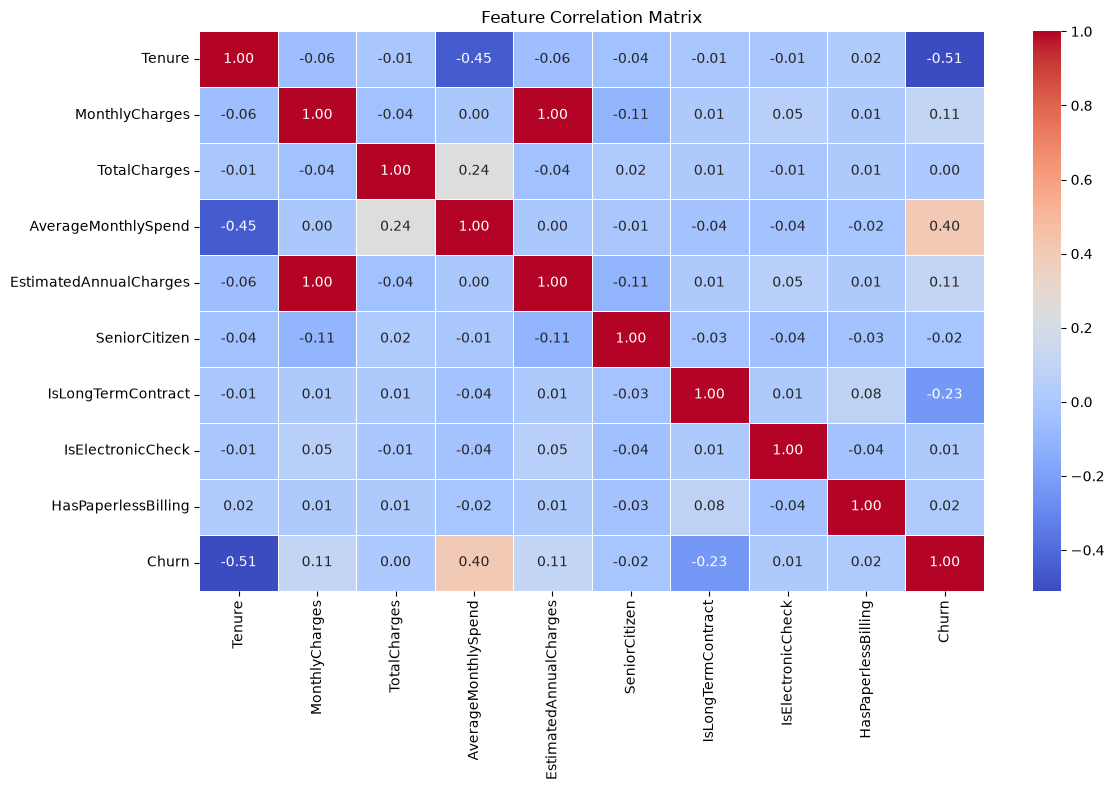

In [66]:
# Correlation heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [67]:
# Churn rate by tenure group

tenure_group_churn = (
    df_engineered
    .groupby("TenureGroup", observed=False)["Churn"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

tenure_group_churn["ChurnRatePercentage"] = (
    tenure_group_churn["mean"] * 100
)

tenure_group_churn

,TenureGroup,count,sum,mean,ChurnRatePercentage
0,New Customer,84,53,0.630952,63.095238
1,Short Term,75,0,0.000000,0.000000
2,Medium Term,171,0,0.000000,0.000000
3,Long Term,170,0,0.000000,0.000000


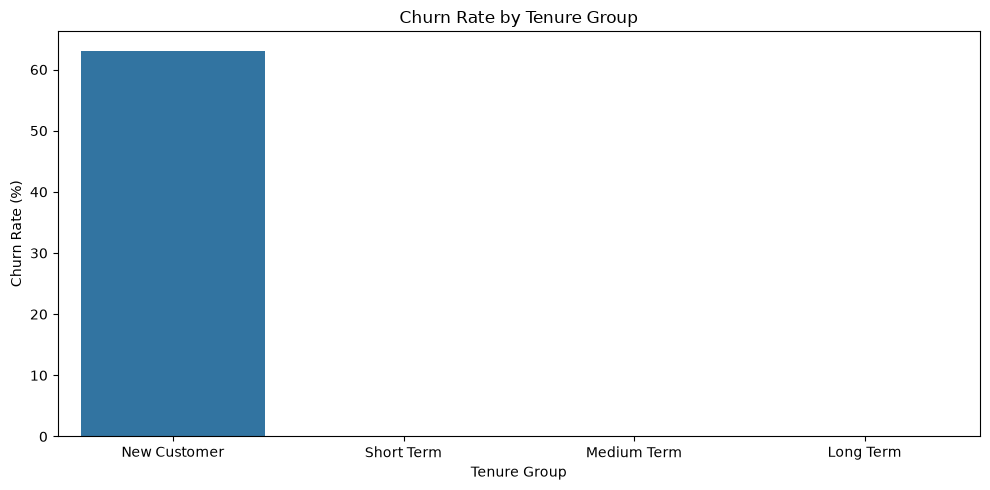

In [68]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=tenure_group_churn,
    x="TenureGroup",
    y="ChurnRatePercentage"
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [69]:
# Churn rate by contract type

contract_churn = (
    df_engineered
    .groupby("Contract")["Churn"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

contract_churn["ChurnRatePercentage"] = (
    contract_churn["mean"] * 100
)

contract_churn

,Contract,count,sum,mean,ChurnRatePercentage
0,Month-to-month,170,35,0.205882,20.588235
1,One year,186,8,0.043011,4.301075
2,Two year,144,10,0.069444,6.944444


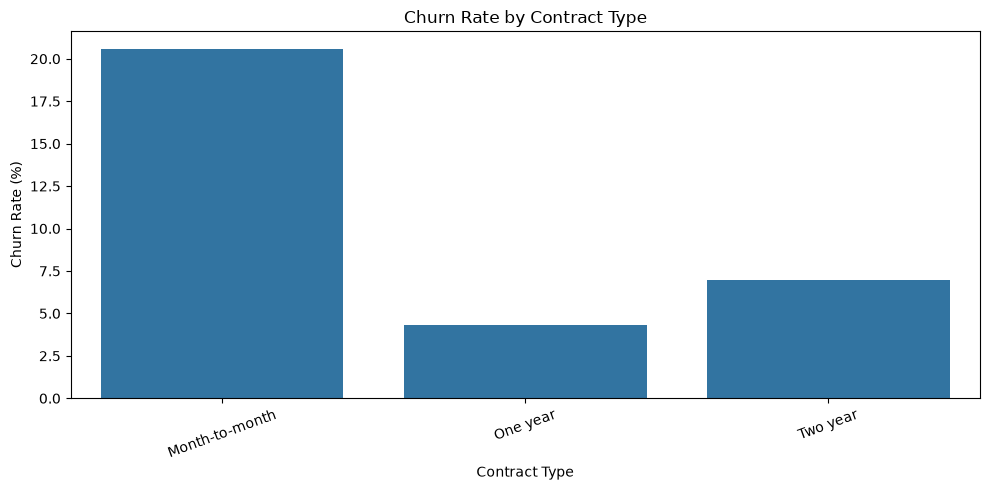

In [70]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=contract_churn,
    x="Contract",
    y="ChurnRatePercentage"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [71]:
# Churn rate by payment method

payment_churn = (
    df_engineered
    .groupby("PaymentMethod")["Churn"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

payment_churn["ChurnRatePercentage"] = (
    payment_churn["mean"] * 100
)

payment_churn

,PaymentMethod,count,sum,mean,ChurnRatePercentage
0,Bank Transfer,159,11,0.069182,6.918239
1,Credit Card,178,24,0.134831,13.483146
2,Electronic Check,163,18,0.110429,11.042945


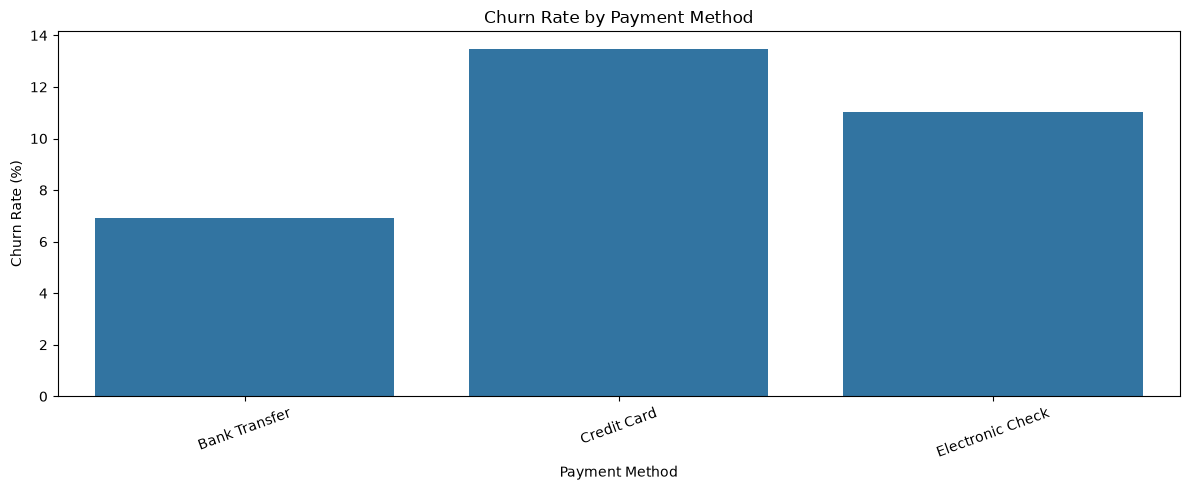

In [72]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=payment_churn,
    x="PaymentMethod",
    y="ChurnRatePercentage"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [73]:
# Check tenure group distribution

print("Tenure group distribution:")
display(df_engineered["TenureGroup"].value_counts().sort_index())

print("\nChurn rate by tenure group:")
display(tenure_group_churn)

Tenure group distribution:


TenureGroup
New Customer     84
Short Term       75
Medium Term     171
Long Term       170
Name: count, dtype: int64


Churn rate by tenure group:


,TenureGroup,count,sum,mean,ChurnRatePercentage
0,New Customer,84,53,0.630952,63.095238
1,Short Term,75,0,0.000000,0.000000
2,Medium Term,171,0,0.000000,0.000000
3,Long Term,170,0,0.000000,0.000000


## Random Forest Feature Importance

In [74]:
# Create a copy for feature importance

df_model = df_engineered.copy()

# Remove unnecessary and redundant columns
df_model = df_model.drop(
    columns=[
        "CustomerID",
        "Churn",
        "EstimatedAnnualCharges"
    ]
)

# Convert categorical features into numerical features
df_model = pd.get_dummies(
    df_model,
    columns=[
        "Contract",
        "PaymentMethod",
        "PaperlessBilling",
        "TenureGroup"
    ],
    drop_first=False
)

# Convert only boolean columns to integers
boolean_columns = df_model.select_dtypes(
    include=["bool"]
).columns

df_model[boolean_columns] = (
    df_model[boolean_columns].astype(int)
)

print("Model feature shape:", df_model.shape)

display(df_model.head())

Model feature shape: (500, 20)


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,AverageMonthlySpend,IsLongTermContract,IsElectronicCheck,HasPaperlessBilling,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank Transfer,PaymentMethod_Credit Card,PaymentMethod_Electronic Check,PaperlessBilling_No,PaperlessBilling_Yes,TenureGroup_New Customer,TenureGroup_Short Term,TenureGroup_Medium Term,TenureGroup_Long Term
0,6,64,1540,1,256.666667,1,0,0,0,1,0,0,1,0,1,0,1,0,0,0
1,21,113,1753,1,83.476190,0,1,1,1,0,0,0,0,1,0,1,0,1,0,0
2,27,31,1455,1,53.888889,1,0,0,0,0,1,0,1,0,1,0,0,0,1,0
3,53,29,7150,1,134.905660,0,1,0,1,0,0,0,0,1,1,0,0,0,0,1
4,16,185,1023,1,63.937500,1,1,0,0,1,0,0,0,1,1,0,0,1,0,0


In [75]:
# Define input features and target

X = df_model
y = df_engineered["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (500, 20)
Target shape: (500,)

Target distribution:
Churn
0    447
1     53
Name: count, dtype: int64


In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (400, 20)
Testing features: (100, 20)
Training target: (400,)
Testing target: (100,)


In [77]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [78]:
# Calculate feature importance

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance_df)

,Feature,Importance
0,Tenure,0.318825
1,TenureGroup_New Customer,0.302669
2,AverageMonthlySpend,0.121389
3,TenureGroup_Long Term,0.047760
4,TenureGroup_Medium Term,0.046380
5,MonthlyCharges,0.035180
6,TotalCharges,0.027288
7,IsLongTermContract,0.021991
8,Contract_One year,0.018545
9,Contract_Month-to-month,0.016791


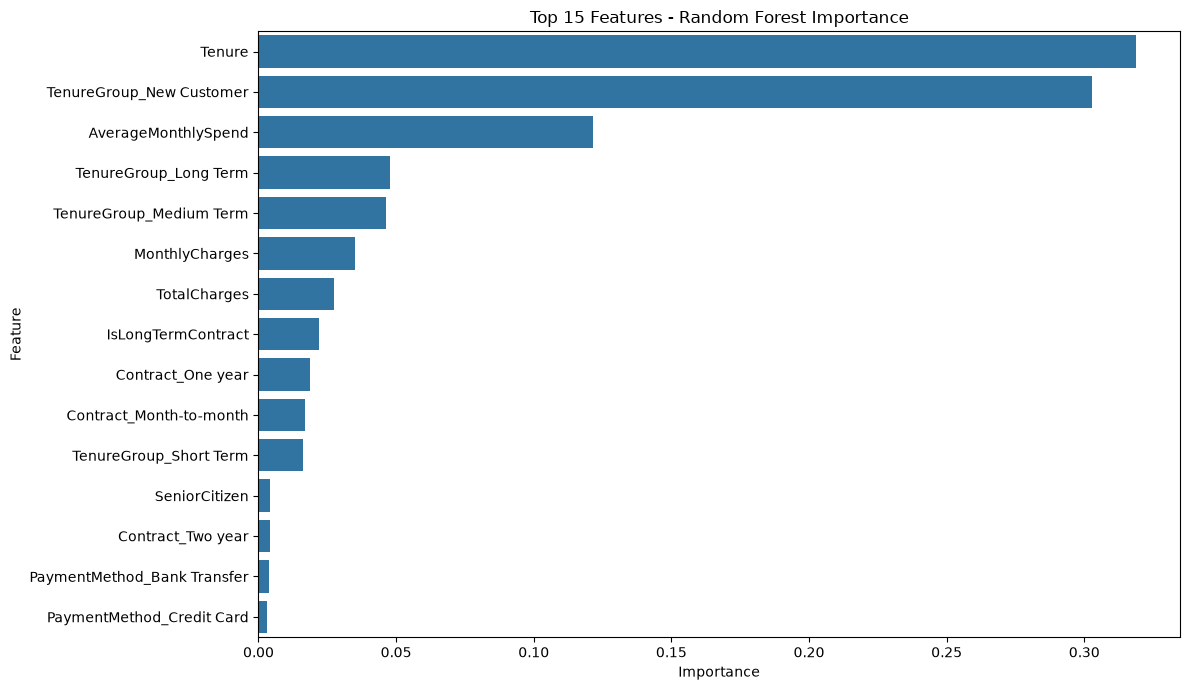

In [79]:
# Select top 15 features

top_features = feature_importance_df.head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features - Random Forest Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import pandas as pd

In [81]:
# Create models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

# Train each model

for model_name, model in models.items():

    model.fit(X_train, y_train)

    print(f"{model_name} trained successfully!")

d:\THE DEVELOPERS ARENA\Week10-Customer-Churn-Prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!


In [82]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Training data scaled successfully!")
print("Training scaled shape:", X_train_scaled.shape)
print("Testing scaled shape:", X_test_scaled.shape)

Training data scaled successfully!
Training scaled shape: (400, 20)
Testing scaled shape: (100, 20)


In [83]:
# Create a scaled Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=42
)

# Train using scaled features
logistic_model.fit(X_train_scaled, y_train)

print("Scaled Logistic Regression trained successfully!")

Scaled Logistic Regression trained successfully!


In [84]:
print("Available models:")

for model_name in models:
    print("-", model_name)

Available models:
- Logistic Regression
- Decision Tree
- Random Forest


In [85]:
# Make predictions using scaled test data

logistic_predictions = logistic_model.predict(X_test_scaled)

logistic_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Logistic Regression predictions completed!")

Logistic Regression predictions completed!


In [86]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, logistic_predictions),
    "Precision": precision_score(
        y_test,
        logistic_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        logistic_predictions,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        logistic_predictions,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        logistic_probabilities
    )
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.97,
 'Precision': 0.7857142857142857,
 'Recall': 1.0,
 'F1 Score': 0.88,
 'ROC-AUC': 0.9979570990806945}